# 28 — Calculate total FRTB SA capital and market RWA

Add SBM, the three DRC charges and RRAO, then convert capital to market risk-weighted assets.

Risk-weighted assets (RWA) express capital on the Basel 8% capital-ratio scale. The factor 12.5 is the inverse of 8%.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml
from IPython.display import display
from frtb_engine.notebook_tools import (
    INR_CRORE, bar_crore, bar_inr, configure_notebooks, crore_table,
    draw_capital_map, draw_flow, heatmap, percent_columns, display_sample,
)

configure_notebooks()
ROOT = Path.cwd()
if not (ROOT / 'outputs').exists():
    ROOT = ROOT.parent
RUN_ID = (ROOT / 'outputs/latest_run.txt').read_text(encoding='utf-8').strip()
RUN = ROOT / 'outputs' / RUN_ID
print(f'Calculation run used in this notebook: {RUN_ID}')

Calculation run used in this notebook: SA_20260908T033903126517Z


This is the part of the calculation chain being handled here:

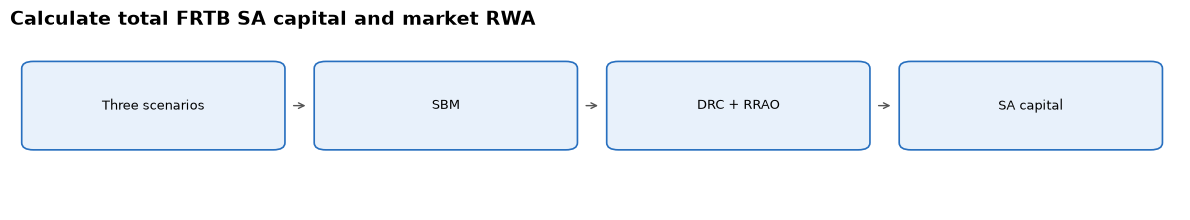

In [2]:
draw_flow(['Three scenarios', 'SBM', 'DRC + RRAO', 'SA capital'],'Calculate total FRTB SA capital and market RWA',wrap_after=4)

Add the components without diversification, then multiply total capital by 12.5.

$$\text{SA capital}=\text{SBM}+\text{DRC}+\text{RRAO}$$

$$\text{Market RWA}=12.5\times\text{SA capital}$$

In [3]:
summary=json.loads((RUN/'16_capital_summary.json').read_text()); drc=pd.read_csv(RUN/'14_drc_summary.csv')
components=pd.DataFrame([
 {'component':'SBM','capital_inr':summary['sbm_capital_inr']},
 {'component':'DRC non-securitisation','capital_inr':drc.loc[drc.drc_class=='NON_SECURITISATION','capital'].iloc[0]},
 {'component':'DRC securitisation non-CTP','capital_inr':drc.loc[drc.drc_class=='SECURITISATION_NON_CTP','capital'].iloc[0]},
 {'component':'DRC securitisation CTP','capital_inr':drc.loc[drc.drc_class=='SECURITISATION_CTP','capital'].iloc[0]},
 {'component':'RRAO','capital_inr':summary['rrao_capital_inr']}])
display(crore_table(components,['capital_inr']))
capital=components.capital_inr.sum()
print(f'Total FRTB SA capital: INR {capital/INR_CRORE:,.4f} crore')
print(f'Market RWA = {capital/INR_CRORE:,.4f} x 12.5 = INR {capital*12.5/INR_CRORE:,.4f} crore')

,component,Capital (INR crore)
0,SBM,91.4954
1,DRC non-securitisation,8.2008
2,DRC securitisation non-CTP,0.3426
3,DRC securitisation CTP,9.3310
4,RRAO,0.1266


Total FRTB SA capital: INR 109.4964 crore
Market RWA = 109.4964 x 12.5 = INR 1,368.7050 crore


The visual below uses the calculated rows shown above.

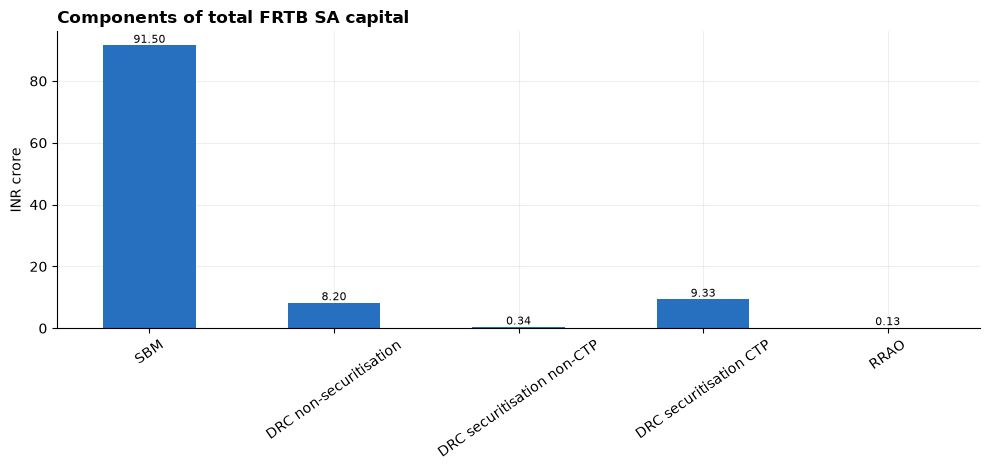

In [4]:
bar_crore(components.set_index('component')['capital_inr'],'Components of total FRTB SA capital')

This is the end-to-end Standardised Approach result for the synthetic portfolio.